This notebook tests the functionality of Acoustic_2D_Cart_Grid.py and PT_model.py by performing forward and ajoint simulations using a model

In [168]:
import numpy as np
from matplotlib import pyplot as plt
from time import time
import PT_model
from PT_model import Acoustic_2D_Cartesian_Grid
import PT_data_classes
from copy import copy
from scipy.ndimage import gaussian_filter


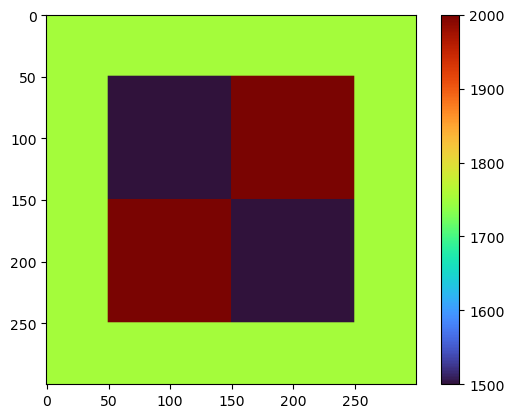

In [169]:
# create Box Model 
c = 1750.0*np.ones((300, 300))
c[50:150,50:150] = 1500.0
c[150:250,50:150] = 2000.0
c[50:150,150:250] = 2000.0
c[150:250,150:250] = 1500.0
# c = gaussian_filter(c, sigma=20)

plt.imshow(c, cmap="turbo")
plt.colorbar()


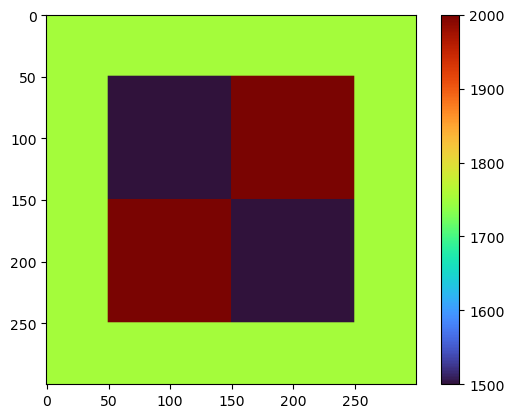

In [170]:

# set model parameters
h = 12.5
Nx = c.shape[1]
Nz = c.shape[0]
ABC_sides = [1, 2, 3, 4]
stacey_ABCs = True
sponge_ABCs = False
sponge_alpha = 1.5
sponge_pnts = 30

model_params = PT_data_classes.Acoustic_2D_Grid_model_params(h=h,
                                                             Nx=Nx,
                                                             Nz=Nz,
                                                             c=c,
                                                             ABC_sides=ABC_sides,
                                                             stacey_ABCs=stacey_ABCs,
                                                             sponge_ABCs=sponge_ABCs,
                                                             sponge_alpha=sponge_alpha,
                                                             sponge_pnts=sponge_pnts)

# initialize instace of the model class
model = Acoustic_2D_Cartesian_Grid(model_params=model_params)

plt.imshow(model.model_params.c, cmap="turbo")
plt.colorbar()


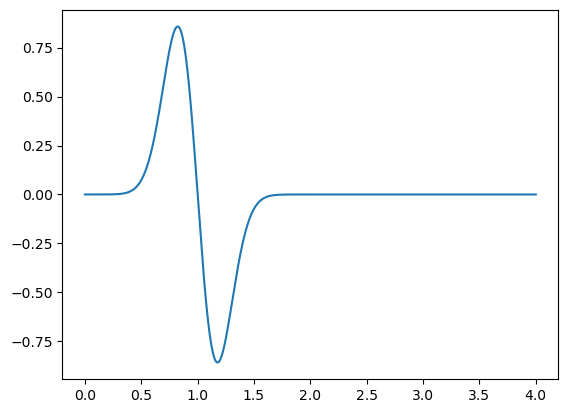

In [171]:
# set time parameters
T_max = 4.0
delta_t = h / (2.0 * np.max(c))  # CFL condition
Nt: int = int(T_max / delta_t) + 1
t = np.arange(Nt) * delta_t

# create first derivative of a gaussian STF
STFS = np.zeros((Nt, 1))
f_0 = 1.0
t_0 = 1/f_0
stf = -8. * (t - t_0) * f_0 * (np.exp(-1.0 * (4*f_0) ** 2 * (t - t_0) ** 2))

plt.plot(t, stf)
STFS[:, 0] = stf


In [172]:
# create locations of sources
source_inds = []
source_inds.append((50, 40))

# create locations of receivers
rec_inds = []
for i in range(50, 250, 1):
	rec_inds.append((i, 260))
	
# initioalize aquisition parameters
aquisition_params = PT_data_classes.Aquisition_params(Nt=Nt,
                                                      delta_t=delta_t,
                                                      STFS=STFS,
                                                      source_inds=source_inds,
                                                      rec_inds=rec_inds)

# create save indice
save_inds = np.arange(0, Nt+1).tolist()
save_inds = save_inds[::5]
print(len(save_inds))

257


In [173]:
# call the forward solver

start = time()

u_out, SG = model.forward(aquisition_params=aquisition_params,
                    save_inds=save_inds)[0:2]
end = time()

print(end-start)

0.4039187431335449


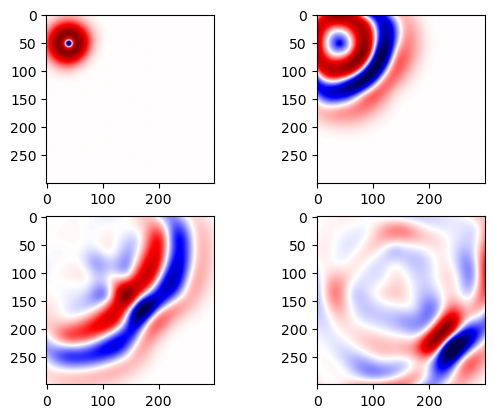

In [174]:
plt_inds = [50, 100, 150, 200]

for i in range(len(plt_inds)): 
	plt_ind = plt_inds[i]
	plt.subplot(2, 2, i+1)
	plt.imshow(u_out[plt_ind], 
			vmax=1*np.max(u_out[plt_inds[i]]), 
			vmin=-1*np.max(u_out[plt_inds[i]]), 
			cmap="seismic")

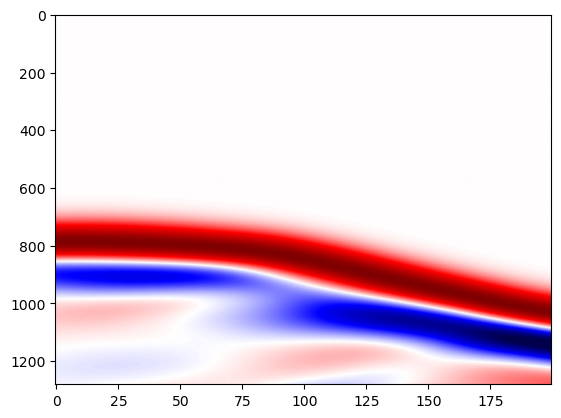

In [175]:
# plot shot gather
plt.imshow(SG/np.max(SG, axis=0), aspect="auto", cmap="seismic", vmax=1, vmin=-1)

In [176]:
# initialize adjoint aquisition parameters
adj_STFS = np.flip(SG - np.roll(SG, -10, axis=0), axis=0)

adj_aquisition_params = copy(aquisition_params)
adj_aquisition_params.STFS = adj_STFS
adj_aquisition_params.source_inds = rec_inds

# call the adjoint solver
start = time()
adj_out, adj_SG, SK, HK = model.adjoint(aquisition_params=adj_aquisition_params,
                    save_inds=save_inds,
                    u_prev=None,
                    u=None,
                    wave_fields=u_out,
                    compute_hessian_kernel=True,
                    save_adjoint_wavefield=False)
end = time()

print(end-start)

0.5417227745056152


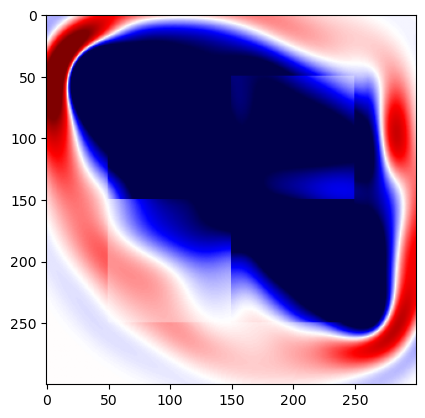

In [177]:
# plot the sensitivity kernel
plt.imshow(SK, cmap="seismic", vmax=0.1*np.max(np.abs(SK)), vmin=-0.1*np.max(np.abs(SK)))

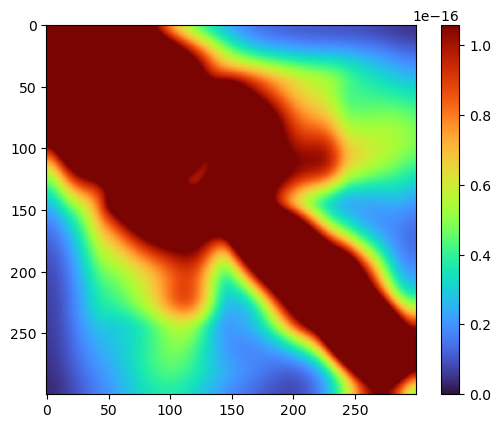

In [178]:
plt.imshow(HK, cmap="turbo", vmax=0.01*np.max(np.abs(HK)), vmin=0.0)
plt.colorbar()

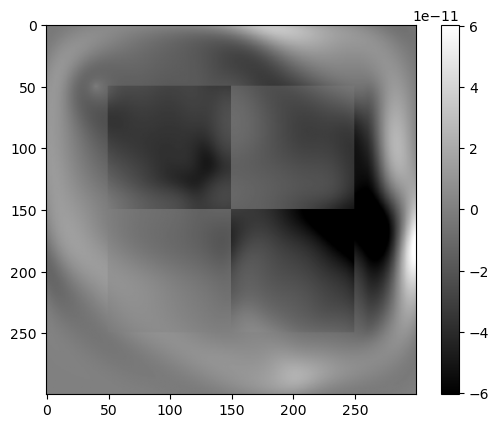

In [179]:
I = SK / (HK)
plt.imshow(I, cmap="gray", vmin=-0.5*np.max(np.abs(I)), vmax=0.5*np.max(np.abs(I)))
plt.colorbar()

In [180]:

path = "Box_Model"
model.save_model(path)


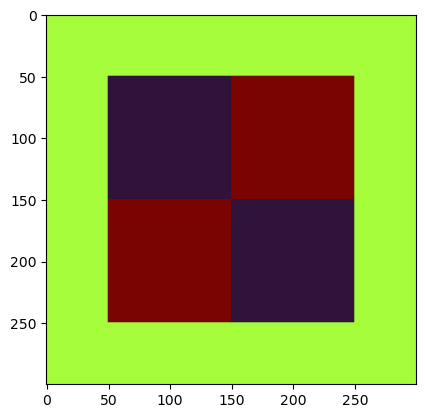

In [181]:

test = PT_model.load_model(path=path)

plt.imshow(test.model_params.c, cmap="turbo")
